# 02 · Segmentación de mercados y clustering

## Objetivo

El EDA de negocio mostró que **no todos los mercados tienen la misma capacidad de optimización**. La mayoría de las combinaciones `Tratamiento + Ciudad` dispone de un único proveedor, mientras que los mercados con alternativas concentran una parte importante del volumen y del gasto.

Este notebook responde:

> **Dentro de los mercados con competencia, ¿qué tipos de mercados existen y en cuáles tiene sentido priorizar ML + optimización?**

La unidad de análisis sigue siendo:

**Mercado = Tratamiento + Ciudad**

### Enfoque

1. Construir métricas por mercado.
2. Medir concentración histórica mediante HHI normalizado.
3. Incorporar evidencia histórica de los proveedores.
4. Seleccionar variables no redundantes para clustering.
5. Evaluar diferentes valores de `K`.
6. Caracterizar los clusters obtenidos.
7. Seleccionar el segmento inicial para la PoC.

**Importante:** el clustering es una herramienta de segmentación estratégica. No determina por sí solo ahorro ni selección de proveedor.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidatos = [
    Path("/content/datos tratramiento detalleV4.xlsx"),
    Path("/mnt/data/datos tratramiento detalleV4.xlsx"),
    Path("datos tratramiento detalleV4.xlsx"),
]

DATA_PATH = next((p for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró 'datos tratramiento detalleV4.xlsx'. "
        "Cárgalo en Colab o ajusta DATA_PATH."
    )

df = pd.read_excel(DATA_PATH)

# Misma regla de calidad definida en el EDA.
df = df[df["SUMA"] > 0].copy()

print(f"Servicios válidos: {len(df):,}")
print(f"Proveedores: {df['CODPROVEEDOR'].nunique():,}")
print(f"Tratamientos: {df['CODIGO_TRATAMIENTO'].nunique():,}")
print(f"Municipios: {df['CODIGO_MUNICIPIO'].nunique():,}")

Servicios válidos: 72,390
Proveedores: 297
Tratamientos: 705
Municipios: 67


## 1. Dataset de mercados

Para cada `Tratamiento + Ciudad` se calculan métricas de tamaño, alternativas, coste y gasto.

In [2]:
mercados = (
    df.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "DESCPROCED",
            "CODIGO_MUNICIPIO",
            "DESCMUNICIPIO"
        ]
    )
    .agg(
        SERVICIOS=("IDEPREADMIN", "size"),
        PROVEEDORES=("CODPROVEEDOR", "nunique"),
        GASTO_TOTAL=("SUMA", "sum"),
        COSTO_PROMEDIO=("SUMA", "mean"),
        COSTO_MEDIANA=("SUMA", "median"),
        COSTO_MIN=("SUMA", "min"),
        COSTO_MAX=("SUMA", "max")
    )
    .reset_index()
)

mercados["SERVICIOS_PROMEDIO_PROVEEDOR"] = (
    mercados["SERVICIOS"] / mercados["PROVEEDORES"]
)

print(f"Mercados Tratamiento + Ciudad: {len(mercados):,}")
display(mercados.head())

Mercados Tratamiento + Ciudad: 6,246


,CODIGO_TRATAMIENTO,DESCPROCED,CODIGO_MUNICIPIO,DESCMUNICIPIO,SERVICIOS,PROVEEDORES,GASTO_TOTAL,COSTO_PROMEDIO,COSTO_MEDIANA,COSTO_MIN,COSTO_MAX,SERVICIOS_PROMEDIO_PROVEEDOR
0,101000001,NEUROCIRUGIA CONSULTA 1A VEZ,001-002-002,CHACAO,2,1,49.680,24.840,24.840,24.680,25.000,2.000
1,101000001,NEUROCIRUGIA CONSULTA 1A VEZ,001-002-004,LIBERTADOR,148,8,"3,604.280",24.353,24.485,21.730,25.000,18.500
2,101000001,NEUROCIRUGIA CONSULTA 1A VEZ,001-002-005,SUCRE,4,1,96.040,24.010,23.910,23.660,24.560,4.000
3,101000001,NEUROCIRUGIA CONSULTA 1A VEZ,003-009-003,BOLIVAR,2,1,50.000,25.000,25.000,25.000,25.000,2.000
4,101000001,NEUROCIRUGIA CONSULTA 1A VEZ,005-003-004,GIRARDOT,31,4,805.860,25.995,24.800,23.490,35.000,7.750


## 2. Concentración histórica de asignaciones

El número de proveedores no indica cómo se distribuyó históricamente el volumen. Para medir concentración utilizamos el **Herfindahl-Hirschman Index (HHI)**.

Sin embargo, el HHI bruto depende matemáticamente del número de proveedores: un mercado perfectamente equilibrado con 2 proveedores tiene HHI=0,5, mientras que uno con 10 proveedores tiene HHI=0,1.

Para evitar duplicar parcialmente la información contenida en `PROVEEDORES`, se utiliza el **HHI normalizado**:

\[
HHI_{norm} = \frac{HHI - 1/N}{1 - 1/N}
\]

Interpretación:

- `0` → reparto perfectamente equilibrado para ese número de proveedores.
- `1` → concentración total.

In [3]:
participacion_proveedor = (
    df.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "CODIGO_MUNICIPIO",
            "CODPROVEEDOR"
        ]
    )
    .size()
    .reset_index(name="SERVICIOS_PROVEEDOR")
)

participacion_proveedor["TOTAL_MERCADO"] = (
    participacion_proveedor
    .groupby(
        ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]
    )["SERVICIOS_PROVEEDOR"]
    .transform("sum")
)

participacion_proveedor["PARTICIPACION"] = (
    participacion_proveedor["SERVICIOS_PROVEEDOR"]
    / participacion_proveedor["TOTAL_MERCADO"]
)

participacion_proveedor["PARTICIPACION_CUADRADO"] = (
    participacion_proveedor["PARTICIPACION"] ** 2
)

hhi = (
    participacion_proveedor
    .groupby(
        ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]
    )
    .agg(
        HHI=("PARTICIPACION_CUADRADO", "sum"),
        PARTICIPACION_MAX=("PARTICIPACION", "max")
    )
    .reset_index()
)

display(hhi.head())

,CODIGO_TRATAMIENTO,CODIGO_MUNICIPIO,HHI,PARTICIPACION_MAX
0,101000001,001-002-002,1.000,1.000
1,101000001,001-002-004,0.398,0.595
2,101000001,001-002-005,1.000,1.000
3,101000001,003-009-003,1.000,1.000
4,101000001,005-003-004,0.538,0.710


## 3. Evidencia histórica y dispersión de costes

Además de contar proveedores, queremos saber si las alternativas tienen actividad histórica suficiente.

Se define como **proveedor robusto** aquel con al menos 5 servicios dentro de un mismo mercado. Este umbral se utiliza como diagnóstico de evidencia histórica, no como regla futura de elegibilidad.

In [4]:
# Proveedores con >=5 servicios dentro del mercado.
proveedores_robustos = (
    participacion_proveedor[
        participacion_proveedor["SERVICIOS_PROVEEDOR"] >= 5
    ]
    .groupby(
        ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]
    )
    .agg(
        PROVEEDORES_ROBUSTOS=("CODPROVEEDOR", "nunique"),
        SERVICIOS_PROVEEDORES_ROBUSTOS=("SERVICIOS_PROVEEDOR", "sum")
    )
    .reset_index()
)

# Costes por proveedor.
costos_proveedor = (
    df.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "CODIGO_MUNICIPIO",
            "CODPROVEEDOR"
        ]
    )
    .agg(
        SERVICIOS_PROVEEDOR=("IDEPREADMIN", "size"),
        COSTO_MEDIANA_PROVEEDOR=("SUMA", "median")
    )
    .reset_index()
)

# Brecha entre medianas históricas de proveedores dentro del mercado.
dispersion_precios = (
    costos_proveedor
    .groupby(
        ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]
    )
    .agg(
        PROVEEDORES_COSTO=("CODPROVEEDOR", "nunique"),
        COSTO_PROV_MIN=("COSTO_MEDIANA_PROVEEDOR", "min"),
        COSTO_PROV_MAX=("COSTO_MEDIANA_PROVEEDOR", "max")
    )
    .reset_index()
)

dispersion_precios["BRECHA_COSTO"] = (
    dispersion_precios["COSTO_PROV_MAX"]
    - dispersion_precios["COSTO_PROV_MIN"]
)

dispersion_precios["BRECHA_PCT"] = np.where(
    dispersion_precios["COSTO_PROV_MIN"] > 0,
    (
        dispersion_precios["COSTO_PROV_MAX"]
        / dispersion_precios["COSTO_PROV_MIN"] - 1
    ) * 100,
    np.nan
)

mercados_cluster = (
    mercados
    .merge(
        hhi,
        on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
        how="left"
    )
    .merge(
        proveedores_robustos,
        on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
        how="left"
    )
    .merge(
        dispersion_precios[
            [
                "CODIGO_TRATAMIENTO",
                "CODIGO_MUNICIPIO",
                "BRECHA_COSTO",
                "BRECHA_PCT"
            ]
        ],
        on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
        how="left"
    )
)

mercados_cluster["PROVEEDORES_ROBUSTOS"] = (
    mercados_cluster["PROVEEDORES_ROBUSTOS"]
    .fillna(0)
    .astype(int)
)

mercados_cluster["SERVICIOS_PROVEEDORES_ROBUSTOS"] = (
    mercados_cluster["SERVICIOS_PROVEEDORES_ROBUSTOS"]
    .fillna(0)
)

mercados_cluster["BRECHA_COSTO"] = (
    mercados_cluster["BRECHA_COSTO"].fillna(0)
)

mercados_cluster["BRECHA_PCT"] = (
    mercados_cluster["BRECHA_PCT"].fillna(0)
)

mercados_cluster["HHI_NORMALIZADO"] = np.where(
    mercados_cluster["PROVEEDORES"] > 1,
    (
        mercados_cluster["HHI"]
        - (1 / mercados_cluster["PROVEEDORES"])
    )
    /
    (
        1 - (1 / mercados_cluster["PROVEEDORES"])
    ),
    1
)

mercados_cluster["PCT_PROVEEDORES_ROBUSTOS"] = (
    mercados_cluster["PROVEEDORES_ROBUSTOS"]
    / mercados_cluster["PROVEEDORES"]
)

mercados_cluster["PCT_VOLUMEN_ROBUSTO"] = (
    mercados_cluster["SERVICIOS_PROVEEDORES_ROBUSTOS"]
    / mercados_cluster["SERVICIOS"]
)

display(
    mercados_cluster[
        [
            "SERVICIOS",
            "PROVEEDORES",
            "PROVEEDORES_ROBUSTOS",
            "PCT_VOLUMEN_ROBUSTO",
            "COSTO_MEDIANA",
            "BRECHA_PCT",
            "HHI_NORMALIZADO",
            "PARTICIPACION_MAX"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
SERVICIOS,"6,246.000",11.590,36.994,1.000,1.000,2.000,7.000,"1,210.000"
PROVEEDORES,"6,246.000",1.483,1.098,1.000,1.000,1.000,2.000,16.000
PROVEEDORES_ROBUSTOS,"6,246.000",0.419,0.816,0.000,0.000,0.000,1.000,11.000
PCT_VOLUMEN_ROBUSTO,"6,246.000",0.283,0.434,0.000,0.000,0.000,0.857,1.000
COSTO_MEDIANA,"6,246.000",960.329,"1,929.582",1.600,30.000,55.292,"1,082.224","43,192.220"
BRECHA_PCT,"6,246.000",148.057,"1,884.373",0.000,0.000,0.000,1.177,"52,367.367"
HHI_NORMALIZADO,"6,246.000",0.805,0.352,0.000,0.790,1.000,1.000,1.000
PARTICIPACION_MAX,"6,246.000",0.908,0.179,0.175,0.942,1.000,1.000,1.000


## 4. El clustering se aplica solo a mercados con competencia

Los mercados de un único proveedor no tienen una decisión de asignación comparable dentro del mismo `Tratamiento + Ciudad`. Por tanto, el clustering estratégico se restringe a mercados con **2 o más proveedores**.

In [5]:
mercados_competencia = (
    mercados_cluster[
        mercados_cluster["PROVEEDORES"] >= 2
    ]
    .copy()
)

print(f"Mercados competitivos para clustering: {len(mercados_competencia):,}")

display(
    mercados_competencia[
        [
            "HHI",
            "HHI_NORMALIZADO",
            "PARTICIPACION_MAX",
            "PCT_PROVEEDORES_ROBUSTOS",
            "PCT_VOLUMEN_ROBUSTO"
        ]
    ].describe(
        percentiles=[.10, .25, .50, .75, .90, .95, .99]
    ).T
)

Mercados competitivos para clustering: 1,654


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
HHI,"1,654.000",0.564,0.174,0.140,0.339,0.477,0.537,0.680,0.835,0.895,0.954,0.989
HHI_NORMALIZADO,"1,654.000",0.264,0.262,0.000,0.000,0.040,0.169,0.444,0.694,0.801,0.909,0.978
PARTICIPACION_MAX,"1,654.000",0.652,0.179,0.175,0.437,0.500,0.667,0.800,0.909,0.944,0.977,0.995
PCT_PROVEEDORES_ROBUSTOS,"1,654.000",0.329,0.330,0.000,0.000,0.000,0.333,0.500,0.800,1.000,1.000,1.000
PCT_VOLUMEN_ROBUSTO,"1,654.000",0.505,0.441,0.000,0.000,0.000,0.714,0.929,0.990,1.000,1.000,1.000


### Hallazgos previos al clustering

En los 1.654 mercados competitivos:

- La mediana del `HHI_NORMALIZADO` es aproximadamente **0,169**.
- La participación mediana del proveedor dominante es aproximadamente **66,7 %**.
- La mediana de `PCT_VOLUMEN_ROBUSTO` es aproximadamente **71,4 %**.
- Un 25 % de los mercados no tiene volumen atendido por proveedores que alcancen 5 servicios históricos.

Esto muestra que tener alternativas nominales no implica necesariamente disponer de alternativas igualmente sólidas.

## 5. Redundancia entre variables

In [6]:
variables_candidatas = [
    "SERVICIOS",
    "PROVEEDORES",
    "PROVEEDORES_ROBUSTOS",
    "SERVICIOS_PROMEDIO_PROVEEDOR",
    "GASTO_TOTAL",
    "COSTO_MEDIANA",
    "BRECHA_PCT",
    "HHI_NORMALIZADO",
    "PARTICIPACION_MAX"
]

correlaciones = (
    mercados_competencia[
        variables_candidatas
    ]
    .corr(method="spearman")
)

display(correlaciones.round(2))

,SERVICIOS,PROVEEDORES,PROVEEDORES_ROBUSTOS,SERVICIOS_PROMEDIO_PROVEEDOR,GASTO_TOTAL,COSTO_MEDIANA,BRECHA_PCT,HHI_NORMALIZADO,PARTICIPACION_MAX
SERVICIOS,1.000,0.520,0.890,0.970,0.270,-0.380,-0.020,0.650,0.350
PROVEEDORES,0.520,1.000,0.460,0.310,0.250,-0.150,0.230,0.110,-0.330
PROVEEDORES_ROBUSTOS,0.890,0.460,1.000,0.860,0.240,-0.340,-0.040,0.490,0.220
SERVICIOS_PROMEDIO_PROVEEDOR,0.970,0.310,0.860,1.000,0.210,-0.390,-0.090,0.700,0.490
GASTO_TOTAL,0.270,0.250,0.240,0.210,1.000,0.630,0.170,0.090,-0.020
COSTO_MEDIANA,-0.380,-0.150,-0.340,-0.390,0.630,1.000,0.230,-0.270,-0.170
BRECHA_PCT,-0.020,0.230,-0.040,-0.090,0.170,0.230,1.000,-0.050,-0.130
HHI_NORMALIZADO,0.650,0.110,0.490,0.700,0.090,-0.270,-0.050,1.000,0.880
PARTICIPACION_MAX,0.350,-0.330,0.220,0.490,-0.020,-0.170,-0.130,0.880,1.000


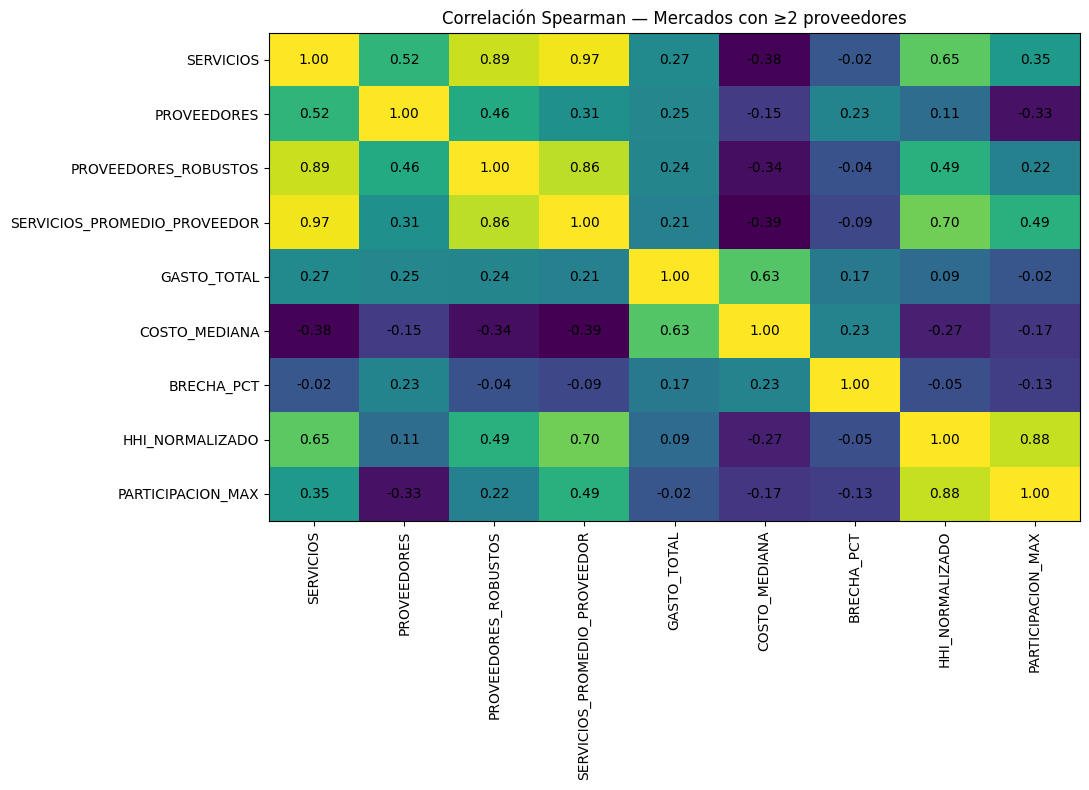

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))

im = ax.imshow(correlaciones.values, aspect="auto")

ax.set_xticks(range(len(correlaciones.columns)))
ax.set_xticklabels(correlaciones.columns, rotation=90)

ax.set_yticks(range(len(correlaciones.index)))
ax.set_yticklabels(correlaciones.index)

for i in range(len(correlaciones.index)):
    for j in range(len(correlaciones.columns)):
        ax.text(
            j, i,
            f"{correlaciones.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlación Spearman — Mercados con ≥2 proveedores")
plt.tight_layout()
plt.show()

In [8]:
cor_robustez = (
    mercados_competencia[
        ["PCT_PROVEEDORES_ROBUSTOS", "PCT_VOLUMEN_ROBUSTO"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Correlación Spearman entre porcentaje de proveedores robustos "
    f"y porcentaje de volumen robusto: {cor_robustez:.3f}"
)

Correlación Spearman entre porcentaje de proveedores robustos y porcentaje de volumen robusto: 0.957


### Decisión de variables

`PCT_PROVEEDORES_ROBUSTOS` y `PCT_VOLUMEN_ROBUSTO` tienen una correlación Spearman cercana a **0,96**, por lo que no se utilizan simultáneamente.

Se conserva `PCT_VOLUMEN_ROBUSTO` porque su interpretación operacional es más directa: mide qué proporción de los servicios del mercado fue atendida por proveedores con evidencia histórica mínima.

Tampoco se utiliza `GASTO_TOTAL`, porque combina volumen y coste y podría sobrerrepresentar dimensiones ya incluidas.

## 6. Variables definitivas para clustering

| Variable | Dimensión de negocio |
|---|---|
| `LOG_SERVICIOS` | Escala / volumen del mercado |
| `PROVEEDORES` | Número de alternativas |
| `PCT_VOLUMEN_ROBUSTO` | Solidez histórica de las alternativas |
| `LOG_COSTO_MEDIANA` | Nivel de coste |
| `LOG_BRECHA_PCT` | Dispersión histórica / oportunidad económica |
| `HHI_NORMALIZADO` | Concentración histórica |

Se aplican transformaciones logarítmicas sobre variables fuertemente asimétricas.

`BRECHA_PCT` se winsoriza en P99 únicamente para evitar que valores extremos dominen la geometría del clustering; los registros originales no se eliminan.

In [9]:
X_cluster = mercados_competencia[
    [
        "SERVICIOS",
        "PROVEEDORES",
        "PCT_VOLUMEN_ROBUSTO",
        "COSTO_MEDIANA",
        "BRECHA_PCT",
        "HHI_NORMALIZADO"
    ]
].copy()

p99_brecha = X_cluster["BRECHA_PCT"].quantile(0.99)

X_cluster["BRECHA_PCT_W"] = (
    X_cluster["BRECHA_PCT"].clip(upper=p99_brecha)
)

X_cluster["LOG_SERVICIOS"] = np.log1p(
    X_cluster["SERVICIOS"]
)

X_cluster["LOG_COSTO_MEDIANA"] = np.log1p(
    X_cluster["COSTO_MEDIANA"]
)

X_cluster["LOG_BRECHA_PCT"] = np.log1p(
    X_cluster["BRECHA_PCT_W"]
)

variables_modelo = [
    "LOG_SERVICIOS",
    "PROVEEDORES",
    "PCT_VOLUMEN_ROBUSTO",
    "LOG_COSTO_MEDIANA",
    "LOG_BRECHA_PCT",
    "HHI_NORMALIZADO"
]

X_modelo = X_cluster[variables_modelo].copy()

print(f"P99 BRECHA_PCT usado para winsorización: {p99_brecha:,.2f}%")
display(X_modelo.describe().T)

P99 BRECHA_PCT usado para winsorización: 16,670.99%


,count,mean,std,min,25%,50%,75%,max
LOG_SERVICIOS,"1,654.000",2.552,1.181,1.099,1.609,2.398,3.296,6.918
PROVEEDORES,"1,654.000",2.823,1.452,2.000,2.000,2.000,3.000,16.000
PCT_VOLUMEN_ROBUSTO,"1,654.000",0.505,0.441,0.000,0.000,0.714,0.929,1.000
LOG_COSTO_MEDIANA,"1,654.000",4.716,1.889,2.117,3.415,3.849,5.238,9.603
LOG_BRECHA_PCT,"1,654.000",3.822,1.789,0.000,2.802,3.909,4.877,9.721
HHI_NORMALIZADO,"1,654.000",0.264,0.262,0.000,0.040,0.169,0.444,0.978


## 7. Escalado robusto

Se utiliza `RobustScaler` porque varias variables presentan asimetría y valores extremos. Este escalador utiliza mediana y rango intercuartílico, reduciendo la sensibilidad a outliers.

In [10]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X_modelo)

print("Shape matriz clustering:", X_scaled.shape)

Shape matriz clustering: (1654, 6)


## 8. Selección del número de clusters

Se evalúan `K=2` a `K=10` utilizando:

- **Inercia:** menor es mejor, pero siempre disminuye al aumentar K.
- **Silhouette:** mayor es mejor.
- **Davies-Bouldin:** menor es mejor.
- **Calinski-Harabasz:** mayor es mejor.

Estas métricas se interpretan conjuntamente con la **utilidad de negocio** de la segmentación.

In [11]:
resultados_k = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = modelo.fit_predict(X_scaled)

    resultados_k.append({
        "K": k,
        "INERCIA": modelo.inertia_,
        "SILHOUETTE": silhouette_score(X_scaled, clusters),
        "DAVIES_BOULDIN": davies_bouldin_score(X_scaled, clusters),
        "CALINSKI_HARABASZ": calinski_harabasz_score(X_scaled, clusters)
    })

resultados_k = pd.DataFrame(resultados_k)

display(resultados_k)

,K,INERCIA,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ
0,2,"5,965.402",0.464,0.974,665.575
1,3,"4,219.018",0.367,0.974,811.954
2,4,"3,514.150",0.292,1.219,759.803
3,5,"2,891.346",0.312,1.135,780.980
4,6,"2,565.240",0.305,1.127,745.686
5,7,"2,358.197",0.316,1.116,699.650
6,8,"2,199.034",0.305,1.105,659.734
7,9,"2,060.107",0.288,1.234,629.689
8,10,"1,929.066",0.293,1.154,609.795


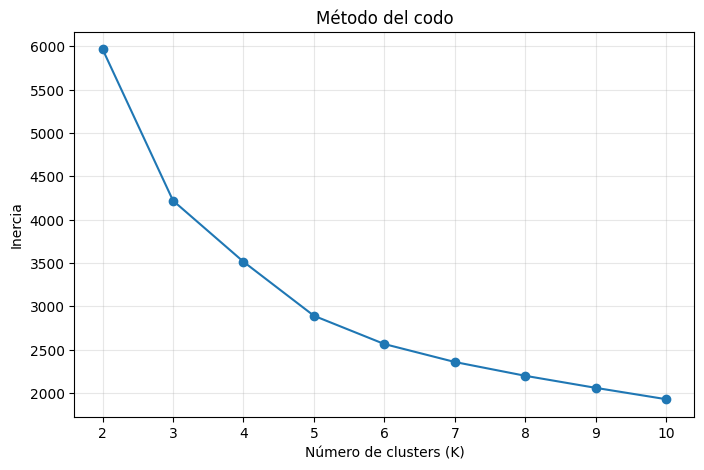

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    resultados_k["K"],
    resultados_k["INERCIA"],
    marker="o"
)

ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Inercia")
ax.set_title("Método del codo")
ax.set_xticks(resultados_k["K"])
ax.grid(alpha=0.3)

plt.show()

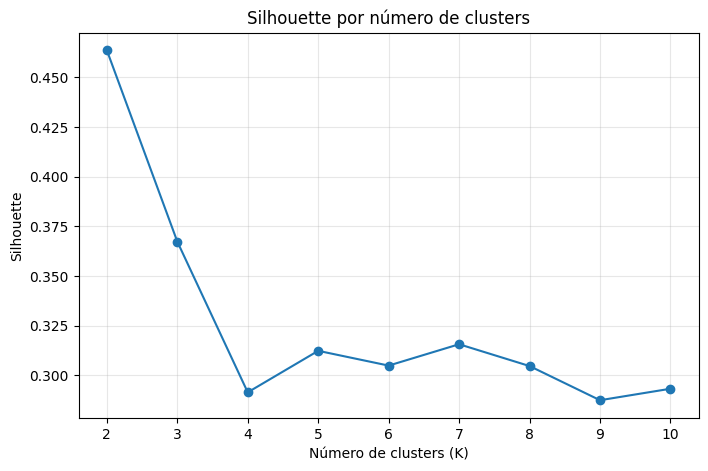

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    resultados_k["K"],
    resultados_k["SILHOUETTE"],
    marker="o"
)

ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Silhouette")
ax.set_title("Silhouette por número de clusters")
ax.set_xticks(resultados_k["K"])
ax.grid(alpha=0.3)

plt.show()

### Selección de K=5

`K=2` obtiene el mayor Silhouette (~0,46), pero genera una partición demasiado gruesa para orientar estrategias diferenciadas de negocio.

A partir de `K=4` el Silhouette se estabiliza aproximadamente entre 0,29 y 0,32. La curva de inercia muestra un cambio de pendiente alrededor de **K=5**; después de ese punto la ganancia marginal disminuye.

Se selecciona:

> **K = 5**

por equilibrio entre separación estadística, estabilidad e interpretabilidad. `K=7` ofrece un Silhouette ligeramente superior, pero la mejora es pequeña y aumenta la complejidad de la segmentación.

## 9. Modelo KMeans final

In [14]:
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=50
)

cluster_5 = kmeans_5.fit_predict(X_scaled)

mercados_competencia["CLUSTER_5"] = cluster_5

silhouette_global = silhouette_score(
    X_scaled,
    cluster_5
)

print(f"Silhouette global K=5: {silhouette_global:.3f}")

Silhouette global K=5: 0.312


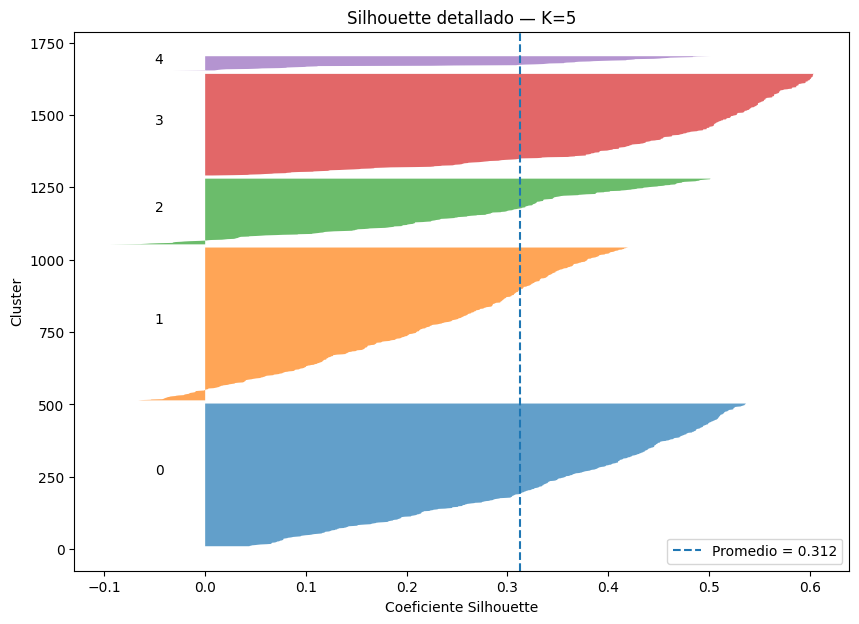

In [15]:
silhouette_valores = silhouette_samples(
    X_scaled,
    cluster_5
)

fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10

for cluster in range(5):

    valores_cluster = silhouette_valores[
        cluster_5 == cluster
    ].copy()

    valores_cluster.sort()

    tamano_cluster = len(valores_cluster)
    y_upper = y_lower + tamano_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        valores_cluster,
        alpha=0.7
    )

    ax.text(
        -0.05,
        y_lower + tamano_cluster / 2,
        str(cluster)
    )

    y_lower = y_upper + 10

ax.axvline(
    silhouette_global,
    linestyle="--",
    label=f"Promedio = {silhouette_global:.3f}"
)

ax.set_title("Silhouette detallado — K=5")
ax.set_xlabel("Coeficiente Silhouette")
ax.set_ylabel("Cluster")
ax.legend()

plt.show()

## 10. Perfil de los cinco clusters

Las etiquetas de KMeans son identificadores numéricos; la interpretación se construye a partir de las características observadas.

In [16]:
resumen_tamano = (
    mercados_competencia
    .groupby("CLUSTER_5")
    .agg(
        MERCADOS=("CODIGO_TRATAMIENTO", "size"),
        SERVICIOS=("SERVICIOS", "sum"),
        GASTO_TOTAL=("GASTO_TOTAL", "sum")
    )
    .reset_index()
)

resumen_tamano["PCT_MERCADOS_COMPETITIVOS"] = (
    resumen_tamano["MERCADOS"]
    / resumen_tamano["MERCADOS"].sum() * 100
)

resumen_tamano["PCT_SERVICIOS_COMPETITIVOS"] = (
    resumen_tamano["SERVICIOS"]
    / resumen_tamano["SERVICIOS"].sum() * 100
)

resumen_tamano["PCT_GASTO_COMPETITIVO"] = (
    resumen_tamano["GASTO_TOTAL"]
    / resumen_tamano["GASTO_TOTAL"].sum() * 100
)

resumen_tamano["PCT_SERVICIOS_TOTAL"] = (
    resumen_tamano["SERVICIOS"]
    / len(df) * 100
)

resumen_tamano["PCT_GASTO_TOTAL"] = (
    resumen_tamano["GASTO_TOTAL"]
    / df["SUMA"].sum() * 100
)

display(
    resumen_tamano.sort_values(
        "SERVICIOS",
        ascending=False
    )
)

,CLUSTER_5,MERCADOS,SERVICIOS,GASTO_TOTAL,PCT_MERCADOS_COMPETITIVOS,PCT_SERVICIOS_COMPETITIVOS,PCT_GASTO_COMPETITIVO,PCT_SERVICIOS_TOTAL,PCT_GASTO_TOTAL
1,1,529,21836,"1,271,500.100",31.983,46.825,11.335,30.164,6.813
2,2,228,12513,"1,666,541.280",13.785,26.833,14.857,17.286,8.930
4,4,51,7733,"2,124,575.420",3.083,16.583,18.941,10.682,11.385
0,0,494,2879,"255,847.510",29.867,6.174,2.281,3.977,1.371
3,3,352,1672,"5,898,610.780",21.282,3.585,52.586,2.310,31.608


In [17]:
perfil_clusters = (
    mercados_competencia
    .groupby("CLUSTER_5")
    .agg(
        MERCADOS=("CODIGO_TRATAMIENTO", "size"),
        SERVICIOS_MEDIANA=("SERVICIOS", "median"),
        SERVICIOS_PROMEDIO=("SERVICIOS", "mean"),
        PROVEEDORES_MEDIANA=("PROVEEDORES", "median"),
        PROVEEDORES_PROMEDIO=("PROVEEDORES", "mean"),
        PCT_VOLUMEN_ROBUSTO_MEDIANA=("PCT_VOLUMEN_ROBUSTO", "median"),
        COSTO_MEDIANA=("COSTO_MEDIANA", "median"),
        BRECHA_PCT_MEDIANA=("BRECHA_PCT", "median"),
        HHI_NORMALIZADO_MEDIANA=("HHI_NORMALIZADO", "median"),
        PARTICIPACION_MAX_MEDIANA=("PARTICIPACION_MAX", "median"),
        GASTO_TOTAL=("GASTO_TOTAL", "sum")
    )
    .reset_index()
)

display(perfil_clusters)

,CLUSTER_5,MERCADOS,SERVICIOS_MEDIANA,SERVICIOS_PROMEDIO,PROVEEDORES_MEDIANA,PROVEEDORES_PROMEDIO,PCT_VOLUMEN_ROBUSTO_MEDIANA,COSTO_MEDIANA,BRECHA_PCT_MEDIANA,HHI_NORMALIZADO_MEDIANA,PARTICIPACION_MAX_MEDIANA,GASTO_TOTAL
0,0,494,5.000,5.828,2.000,2.243,0.000,39.440,56.364,0.083,0.600,"255,847.510"
1,1,529,23.000,41.278,2.000,2.372,0.929,35.650,29.757,0.538,0.857,"1,271,500.100"
2,2,228,32.500,54.882,4.000,4.539,0.869,35.000,79.504,0.181,0.514,"1,666,541.280"
3,3,352,3.000,4.750,2.000,2.344,0.000,"3,199.240",54.356,0.030,0.500,"5,898,610.780"
4,4,51,105.000,151.627,8.000,8.745,0.938,31.200,86.481,0.219,0.484,"2,124,575.420"


In [18]:
sil_individual = silhouette_samples(X_scaled, cluster_5)

mercados_competencia["SILHOUETTE_INDIVIDUAL"] = sil_individual

sil_cluster = (
    mercados_competencia
    .groupby("CLUSTER_5")["SILHOUETTE_INDIVIDUAL"]
    .agg(["count", "mean", "median", "min"])
    .reset_index()
)

display(sil_cluster)

,CLUSTER_5,count,mean,median,min
0,0,494,0.341,0.364,0.044
1,1,529,0.214,0.232,-0.067
2,2,228,0.265,0.298,-0.095
3,3,352,0.455,0.505,0.008
4,4,51,0.279,0.342,-0.033


### Interpretación de negocio

| Cluster | Perfil | Estrategia |
|---|---|---|
| **0** | Baja escala / baja evidencia | Poco prioritario para ML; reglas y baremo actual |
| **1** | Alto volumen / pocos proveedores / alta concentración | Diversificación y capacidad |
| **2** | Volumen medio-alto / varios proveedores / alta brecha | Oportunidad económica; expansión posterior |
| **3** | Muy bajo volumen / muy alto coste | Alta severidad / baja frecuencia; enfoque específico |
| **4** | Muy alto volumen / muchos proveedores / alta brecha | **Segmento estratégico prioritario para PoC** |

El clustering no pretende afirmar que unos mercados sean “buenos” y otros “malos”. Su función es asignar **estrategias diferentes** según estructura, volumen, coste y evidencia.

## 11. Perfil relativo de los clusters

Para facilitar la interpretación visual, las medianas de cada cluster se normalizan entre 0 y 1. Esta normalización se utiliza **solo para visualización**, no para entrenar KMeans.

In [19]:
perfil_visual = (
    mercados_competencia
    .groupby("CLUSTER_5")
    .agg(
        SERVICIOS=("SERVICIOS", "median"),
        PROVEEDORES=("PROVEEDORES", "median"),
        PCT_VOLUMEN_ROBUSTO=("PCT_VOLUMEN_ROBUSTO", "median"),
        COSTO_MEDIANA=("COSTO_MEDIANA", "median"),
        BRECHA_PCT=("BRECHA_PCT", "median"),
        HHI_NORMALIZADO=("HHI_NORMALIZADO", "median")
    )
)

scaler_visual = MinMaxScaler()

perfil_normalizado = pd.DataFrame(
    scaler_visual.fit_transform(perfil_visual),
    columns=perfil_visual.columns,
    index=perfil_visual.index
)

display(perfil_normalizado.round(2))

,SERVICIOS,PROVEEDORES,PCT_VOLUMEN_ROBUSTO,COSTO_MEDIANA,BRECHA_PCT,HHI_NORMALIZADO
CLUSTER_5,,,,,,
0,0.020,0.000,0.000,0.000,0.470,0.100
1,0.200,0.000,0.990,0.000,0.000,1.000
2,0.290,0.330,0.930,0.000,0.880,0.300
3,0.000,0.000,0.000,1.000,0.430,0.000
4,1.000,1.000,1.000,0.000,1.000,0.370


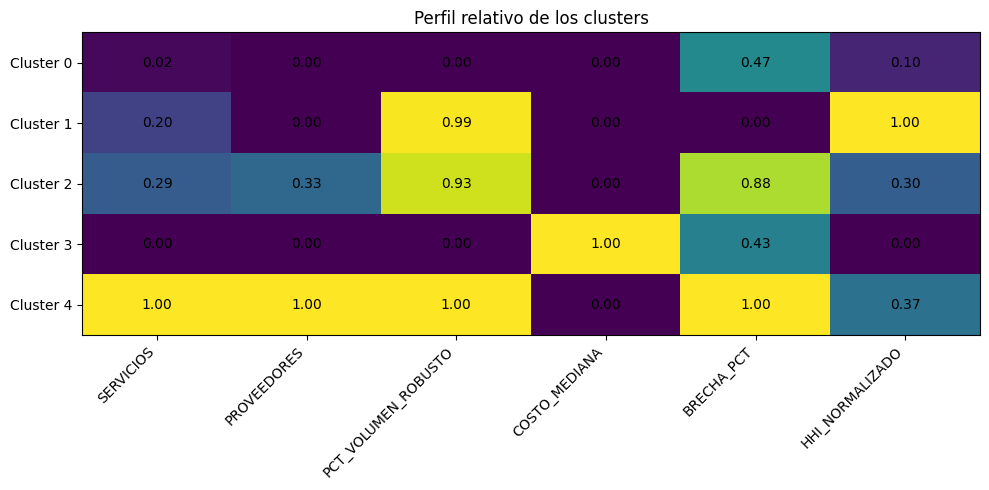

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.imshow(
    perfil_normalizado.values,
    aspect="auto"
)

ax.set_xticks(range(len(perfil_normalizado.columns)))
ax.set_xticklabels(
    perfil_normalizado.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(perfil_normalizado.index)))
ax.set_yticklabels(
    [f"Cluster {i}" for i in perfil_normalizado.index]
)

for i in range(perfil_normalizado.shape[0]):
    for j in range(perfil_normalizado.shape[1]):
        ax.text(
            j,
            i,
            f"{perfil_normalizado.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Perfil relativo de los clusters")
plt.tight_layout()
plt.show()

## 12. PCA para visualización

El clustering se calcula sobre las seis variables escaladas. PCA se utiliza únicamente para proyectarlas a dos dimensiones y visualizar la estructura resultante.

In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

centroides_pca = pca.transform(
    kmeans_5.cluster_centers_
)

print(
    f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.2%}"
)
print(
    f"Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.2%}"
)
print(
    "Varianza explicada total: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

cargas_pca = pd.DataFrame(
    pca.components_.T,
    index=variables_modelo,
    columns=["PC1", "PC2"]
)

display(cargas_pca.round(3))

Varianza explicada PC1: 47.27%
Varianza explicada PC2: 26.11%
Varianza explicada total: 73.38%


,PC1,PC2
LOG_SERVICIOS,0.314,-0.275
PROVEEDORES,0.908,0.270
PCT_VOLUMEN_ROBUSTO,0.140,-0.233
LOG_COSTO_MEDIANA,-0.193,0.772
LOG_BRECHA_PCT,0.130,0.327
HHI_NORMALIZADO,0.063,-0.308


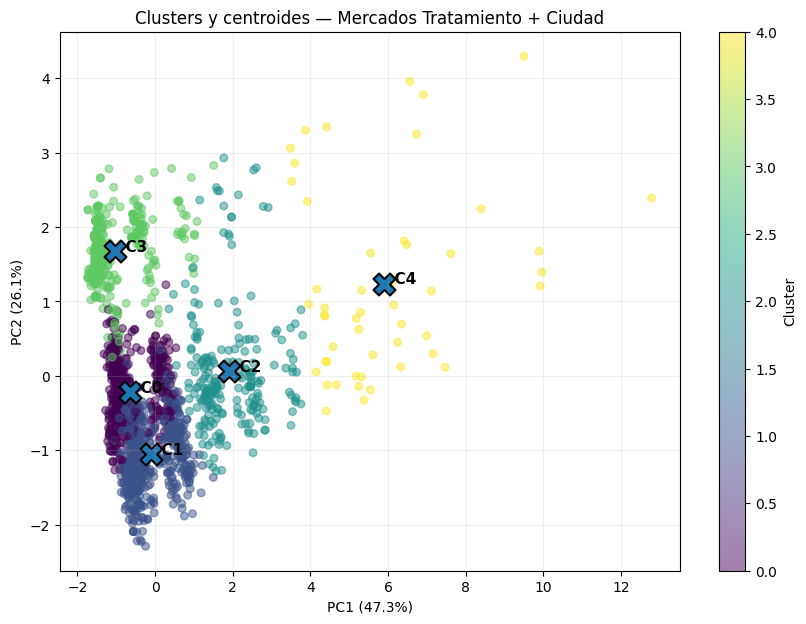

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_5,
    alpha=0.5,
    s=30
)

ax.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5
)

for i in range(5):
    ax.text(
        centroides_pca[i, 0],
        centroides_pca[i, 1],
        f"  C{i}",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"
)
ax.set_title("Clusters y centroides — Mercados Tratamiento + Ciudad")
ax.grid(alpha=0.2)

plt.colorbar(scatter, ax=ax, label="Cluster")
plt.show()

## 13. Peso de cada segmento

Este gráfico permite ver simultáneamente la participación de cada cluster en **volumen** y **gasto** dentro de los mercados competitivos.

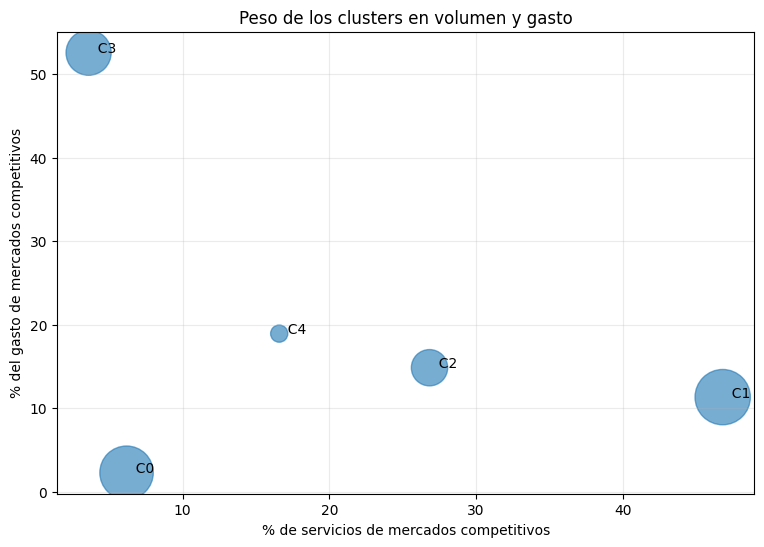

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

x = resumen_tamano["PCT_SERVICIOS_COMPETITIVOS"]
y = resumen_tamano["PCT_GASTO_COMPETITIVO"]
sizes = resumen_tamano["MERCADOS"] * 3

ax.scatter(
    x,
    y,
    s=sizes,
    alpha=0.6
)

for _, fila in resumen_tamano.iterrows():
    ax.text(
        fila["PCT_SERVICIOS_COMPETITIVOS"],
        fila["PCT_GASTO_COMPETITIVO"],
        f"  C{int(fila['CLUSTER_5'])}"
    )

ax.set_xlabel("% de servicios de mercados competitivos")
ax.set_ylabel("% del gasto de mercados competitivos")
ax.set_title("Peso de los clusters en volumen y gasto")
ax.grid(alpha=0.25)

plt.show()

# 14. Lectura de los segmentos y estrategia

### Cluster 0 — Baja escala / baja evidencia

- 494 mercados.
- Mediana de 5 servicios.
- Mediana de 2 proveedores.
- Volumen robusto mediano: 0 %.
- Coste mediano: ~39,44.
- Brecha mediana: ~56,36 %.

**Decisión:** no priorizar forecasting específico en la primera fase. La poca historia hace que la señal temporal y los costes históricos sean menos fiables. Se puede operar inicialmente con baremo actual, calidad, capacidad y reglas simples.

---

### Cluster 1 — Mercados concentrados

- 529 mercados.
- Mediana de 23 servicios.
- Mediana de 2 proveedores.
- Volumen robusto mediano: ~92,9 %.
- HHI normalizado mediano: ~0,538.
- Proveedor dominante mediano: ~85,7 %.

**Decisión:** segmento muy relevante para **diversificación**. Tiene alto volumen y evidencia sólida, pero normalmente pocas alternativas y alta concentración. Se reserva como expansión posterior, una vez incorporadas capacidad y reglas operativas.

---

### Cluster 2 — Oportunidad económica

- 228 mercados.
- Mediana de 32,5 servicios.
- Mediana de 4 proveedores.
- Volumen robusto mediano: ~86,9 %.
- Brecha mediana: ~79,5 %.
- Concentración moderada.

**Decisión:** candidato claro a una segunda fase de optimización económica. Tiene más alternativas y diferencias de coste relevantes.

---

### Cluster 3 — Alta severidad / baja frecuencia

- 352 mercados.
- Mediana de solo 3 servicios.
- Coste mediano: ~3.199.
- Volumen robusto mediano: 0 %.
- Concentra una gran parte del gasto competitivo con muy poco volumen.

**Decisión:** no aplicar inicialmente el mismo forecast semanal. Son casos `low frequency / high severity`; necesitan un enfoque específico basado principalmente en coste unitario vigente, autorización, calidad, capacidad y reglas de negocio.

---

### Cluster 4 — Mercados estratégicos de optimización

- **51 mercados.**
- Mediana de **105 servicios**.
- Promedio de ~152 servicios.
- Mediana de **8 proveedores**.
- Volumen robusto mediano: ~93,8 %.
- Coste mediano: ~31,20.
- Brecha mediana: ~86,5 %.
- Concentración baja/moderada.

**Decisión:** es el segmento inicial de la PoC porque combina las tres condiciones más favorables:

> **alto volumen + múltiples alternativas + diferencias económicas relevantes**

Aquí sí tiene sentido desarrollar un forecast de demanda y, posteriormente, conectar esa demanda con un optimizador de proveedores.

# 15. Decisión metodológica

El clustering confirma que **no aplicaremos ML a todo el histórico de forma indiscriminada**.

La estrategia queda:

- **Cluster 0:** reglas/baremo actual; baja prioridad para ML.
- **Cluster 1:** diversificación y capacidad; expansión posterior.
- **Cluster 2:** optimización económica; expansión posterior.
- **Cluster 3:** enfoque específico de alta severidad/baja frecuencia.
- **Cluster 4:** **PoC inicial de forecast + optimización**.

Por tanto, el siguiente paso es analizar temporalmente únicamente los mercados del Cluster 4 para responder:

> **¿Cuánta demanda semanal esperamos por Tratamiento + Ciudad?**

➡️ **Siguiente notebook: `03_EDA_Temporal_Preparacion.ipynb`**

In [24]:
# Opcional: exportar la segmentación para reutilización en notebooks posteriores.
OUTPUT_CLUSTER = Path("/mnt/data/mercados_cluster_k5.csv")

mercados_competencia.to_csv(
    OUTPUT_CLUSTER,
    index=False
)

print(f"Segmentación exportada en: {OUTPUT_CLUSTER}")

Segmentación exportada en: /mnt/data/mercados_cluster_k5.csv
